In [1]:
import pickle
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad

from PerturbSeqSimulator import PerturbSeqSimulator

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load GRN and control cells

In [2]:
with open("./DATA/grn.pkl", "rb") as f:
    grn = pickle.load(f)

control_adata = sc.read_h5ad("./DATA/control_data_homogenous.h5ad")

print(f"GRN: {grn.n_genes} genes, {grn.n_programs} programs")
print(f"W shape: {grn.W.shape}")
print(f"V shape: {grn.V.shape}")
print(f"Control cells: {control_adata.shape}")
print(f"Available layers: {list(control_adata.layers.keys())}")

GRN: 5000 genes, 10 programs
W shape: (5000, 10)
V shape: (10, 5000)
Control cells: (1000, 5000)
Available layers: ['raw_counts', 'raw_logNorm']


In [3]:
grn

## Initialise the simulator

In [4]:
sim = PerturbSeqSimulator(
    grn=grn,
    control_adata=control_adata,
    counts_layer="raw_counts",
    perturbation_strength=1.0,
    damping_factor=0.5,
    n_propagation_steps=2,
    seed=42,
    verbose=True
)

Pre-computing perturbation effects: 100%|██████████| 860/860 [00:00<00:00, 5130.97it/s]

PerturbSeqSimulator initialized:
  Control cells: 1000
  Perturbable genes: 860
  Propagation steps: 2
  Damping factor: 0.5


## Inspect perturbation effects before simulating

In [5]:
summary = sim.get_effect_summary()
print(f"Total perturbable genes: {len(sim.perturbable_genes)}")
summary

Total perturbable genes: 860


,gene,n_affected_programs,affected_programs,max_abs_program_shift,mean_abs_program_shift,n_genes_affected,max_abs_gene_shift,mean_abs_gene_shift,primary_dominance
0,URB2,5,"apoptosis, dna_repair, metabolism, ribosome_bi...",14.719067,3.023907,537,20.362431,0.379409,0.050957
1,RIOK3,5,"apoptosis, dna_repair, metabolism, ribosome_bi...",13.241287,2.720508,537,18.318063,0.341330,0.051097
2,ZNHIT6,5,"apoptosis, dna_repair, metabolism, ribosome_bi...",12.065573,2.478463,537,16.691575,0.310991,0.050720
3,MTERF3,5,"apoptosis, dna_repair, metabolism, ribosome_bi...",11.717650,2.407024,537,16.210255,0.302025,0.050744
4,TCOF1,5,"apoptosis, dna_repair, metabolism, ribosome_bi...",11.413963,2.344972,537,15.790134,0.294219,0.051016
...,...,...,...,...,...,...,...,...,...
855,STXBP3,6,"cell_cycle, apoptosis, immune_response, oxidat...",0.086641,0.014996,521,0.108775,0.001455,0.115393
856,VAV2,6,"apoptosis, metabolism, oxidative_stress, autop...",0.076537,0.015622,450,0.075224,0.000687,0.515622
857,SYN_ANGIOGENESIS_0006,6,"apoptosis, metabolism, oxidative_stress, autop...",0.041717,0.008512,448,0.040999,0.000374,0.514820
858,SYN_ANGIOGENESIS_0004,6,"apoptosis, metabolism, oxidative_stress, autop...",0.023359,0.004765,440,0.022956,0.000209,0.513937


In [6]:
gt = sim.get_ground_truth_log2fc()  
gt

,ABCF1,ABL1,ACACA,ACBD5,ACKR2,ACKR3,ACLY,ADAM15,ADAM32,ADPRS,...,XCL1,XKR9,XPO1,XRCC5,ZDHHC16,ZNF593,ZNF622,ZNF658,ZNHIT6,ZYX
ABCF1,-inf,-0.002826,-0.057126,0.020614,0.000000,0.000000,-0.058078,-0.033531,0.000000,-0.018290,...,0.000000,0.026503,-4.519268,4.793215,0.020456,5.000000,3.906943,5.000000,3.856463,0.000000
ABL1,-0.006604,-inf,0.013789,3.322018,-0.015648,-0.040632,0.014019,5.000000,-0.057465,0.729817,...,-0.053146,-5.000000,0.005076,-0.005384,-5.000000,-0.006612,-0.004389,-0.006225,-0.004332,-0.067702
ACACA,-0.069088,0.012884,-inf,0.025850,0.000000,0.000000,1.899783,-0.049596,0.000000,0.000000,...,0.000000,0.040395,0.053110,-0.056329,0.031178,-0.069175,-0.045914,-0.065131,-0.045320,0.000000
ACBD5,0.048409,5.000000,0.038561,-inf,-0.006236,0.000000,0.039204,0.279265,0.000000,0.054415,...,-0.021180,-0.222719,-0.037213,0.039469,-0.171902,0.048469,0.032171,0.045636,0.031755,0.000000
ACKR2,0.000000,-0.010609,0.000000,-0.003357,-inf,-0.004700,0.000000,-0.007275,-0.006648,0.000000,...,0.785043,0.005751,0.000000,0.000000,0.004438,0.000000,0.000000,0.000000,0.000000,-0.007832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF593,5.000000,-0.004894,-0.098911,0.035691,0.000000,0.000000,-0.100559,-0.058056,0.000000,-0.031669,...,0.000000,0.045888,-5.000000,5.000000,0.035418,-inf,5.000000,5.000000,5.000000,0.000000
ZNF622,5.000000,-0.002615,-0.052864,0.019076,0.000000,0.000000,-0.053745,-0.031029,0.000000,-0.016926,...,0.000000,0.024526,-4.190454,4.444469,0.018930,5.000000,-inf,5.000000,3.575873,0.000000
ZNF658,3.282901,-0.001574,-0.031822,0.011483,0.000000,0.000000,-0.032352,-0.018678,0.000000,-0.010188,...,0.000000,0.014763,-2.523630,2.676606,0.011395,3.287002,2.181697,-inf,2.153509,0.000000
ZNHIT6,5.000000,-0.008519,-0.172180,0.062130,0.000000,0.000000,-0.175048,-0.101062,0.000000,-0.055127,...,0.000000,0.079880,-5.000000,5.000000,0.061654,5.000000,5.000000,5.000000,-inf,0.000000


In [7]:
# 1. Running sim actually has the new default?                                                                                  
print("sim.nb_sampling =", sim.nb_sampling)            # should be False                                                        
  

sim.nb_sampling = False


In [8]:
with open("./DATA/gt_FCs.pkl", "wb") as f:                                                                                  
      pickle.dump(gt, f)

## Simulate all single-gene knockouts

In [9]:
# Set n_perturbations to None to simulate every perturbable gene.
n_perturbations = 100
genes_to_perturb = (
    sim.perturbable_genes[:n_perturbations] if n_perturbations is not None else None
)

adata = sim.simulate_all_perturbations(
    n_cells_per_perturbation=500,
    count_distribution="negative_binomial",
    include_control=True,
    genes_to_perturb=genes_to_perturb,
)

adata.layers['raw_counts'] = adata.X.copy()


Including 1000 control cells from input AnnData ...


Simulating gene KOs: 100%|██████████| 100/100 [00:04<00:00, 20.44it/s]



Generated AnnData: (51000, 5000)
  Control cells: 1000
  KO conditions: 100
  Cells per KO: 500
  Total perturbed cells: 50000


In [10]:
import numpy as np                                        
print("dispersion (r) percentiles:",
    np.percentile(sim.dispersion, [1, 5, 25, 50, 75, 95, 99]))
print("# genes with r == 1:", (sim.dispersion == 1.0).sum(), "/", sim.dispersion.size)
                                                                                        
  

dispersion (r) percentiles: [5.         5.         5.         5.         5.         5.
 5.86061191]
# genes with r == 1: 0 / 5000


In [11]:
print(np.percentile(sim.dispersion, [1, 5, 25, 50, 75, 95, 99]))   

[5.         5.         5.         5.         5.         5.
 5.86061191]


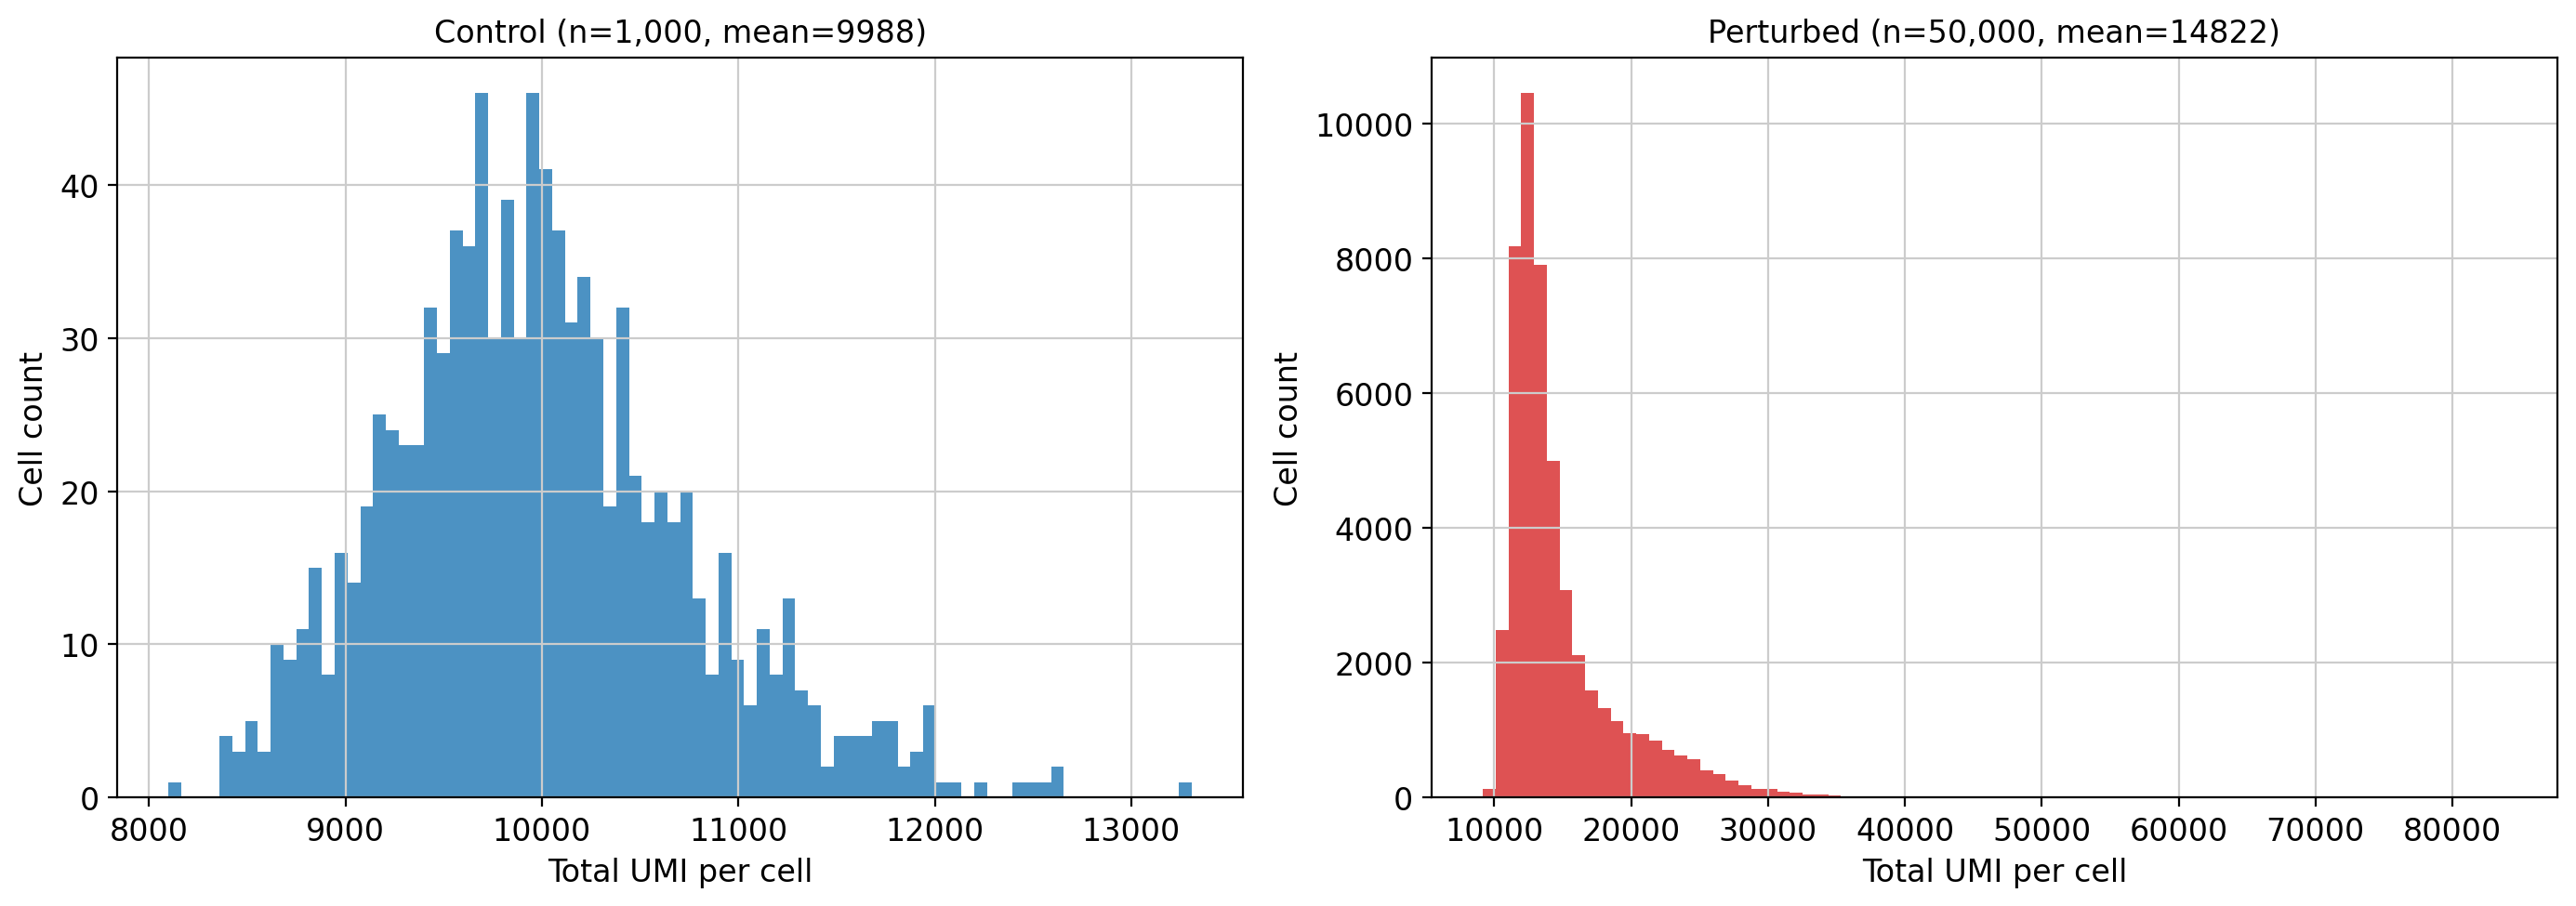

In [12]:
# Total UMI (library size) distribution per cell: control vs perturbed
import matplotlib.pyplot as plt

total_umi = np.asarray(adata.X.sum(axis=1)).ravel()
is_ctrl = adata.obs['is_control'].values

ctrl_umi = total_umi[is_ctrl]
pert_umi = total_umi[~is_ctrl]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].hist(ctrl_umi, bins=80, color='tab:blue', alpha=0.8)
axes[0].set_xlabel('Total UMI per cell')
axes[0].set_ylabel('Cell count')
axes[0].set_title(f'Control (n={ctrl_umi.size:,}, mean={ctrl_umi.mean():.0f})')

axes[1].hist(pert_umi, bins=80, color='tab:red', alpha=0.8)
axes[1].set_xlabel('Total UMI per cell')
axes[1].set_ylabel('Cell count')
axes[1].set_title(f'Perturbed (n={pert_umi.size:,}, mean={pert_umi.mean():.0f})')

plt.tight_layout()
plt.show()

In [13]:
ctrl_umi.mean()

np.float64(9988.078)

In [14]:
pert_umi.mean()

np.float64(14822.037955144238)

In [15]:
print(f"Shape: {adata.shape}")
print(f"Control cells: {(adata.obs['is_control']).sum()}")
print(f"KO conditions: {adata.obs.loc[~adata.obs['is_control'], 'perturbation'].nunique()}")
print(f"Mean counts: {adata.X.mean():.1f}")
print(f"Sparsity: {(adata.X == 0).mean()*100:.1f}%")
adata.obs['perturbation'].value_counts()

Shape: (51000, 5000)
Control cells: 1000
KO conditions: 100
Mean counts: 2.9
Sparsity: 1.4%


perturbation
control    1000
ABCF1       500
ABL1        500
ACACA       500
ACBD5       500
           ... 
CDH4        500
CDH6        500
CDK1        500
CDK11B      500
CDK2        500
Name: count, Length: 101, dtype: int64

In [16]:
adata.write("./DATA/perturbseq_all_KOs.h5ad")


In [17]:
# 1. Is the noise actually on?                                                                                              
print(f"sim.noise_std = {sim.noise_std}")          # should be 0.5


sim.noise_std = 0.5


In [18]:
# Median-of-ratios (poscounts) size factors and normalization
import scipy.sparse as sp

def median_of_ratios_size_factors(X):
    """DESeq2 poscounts-style size factors; robust to zeros in scRNA-seq."""
    X = X.toarray() if sp.issparse(X) else np.asarray(X)
    X = X.astype(np.float64)
    with np.errstate(divide='ignore'):
        log_X = np.where(X > 0, np.log(X), np.nan)
    geom = np.exp(np.nanmean(log_X, axis=0))
    valid = np.isfinite(geom) & (geom > 0)
    ratios = np.where(X[:, valid] > 0, X[:, valid] / geom[valid], np.nan)
    return np.nanmedian(ratios, axis=1)

sf = median_of_ratios_size_factors(adata.X)
adata.obs['size_factor'] = sf

X_raw = adata.X.toarray() if sp.issparse(adata.X) else np.asarray(adata.X)
adata.layers['sf_normalized'] = X_raw.astype(np.float64) / sf[:, np.newaxis]

print(f"Size factors — median {np.median(sf):.3f}, "
      f"mean {sf.mean():.3f}, range [{sf.min():.3f}, {sf.max():.3f}]")

Size factors — median 1.162, mean 1.173, range [1.005, 1.909]


In [19]:
# Pdex Wilcoxon on size-factor-normalized counts
from pdex import parallel_differential_expression
import anndata as ad

# Wrap normalized layer in a minimal AnnData so the original adata.X (raw counts)
# stays untouched for downstream preprocessing cells
adata_sf = ad.AnnData(
    X=adata.layers['sf_normalized'],
    obs=adata.obs.copy(),
    var=adata.var.copy(),
)
degs_sf = parallel_differential_expression(
    adata_sf,
    groupby_key="perturbation",
    reference="control",
    is_log1p=False,
    num_workers=128,
)
degs_sf.to_csv("SimulatedData_degs_sf.csv")
print(f"Wrote SimulatedData_degs_sf.csv: {len(degs_sf)} rows")

INFO:pdex._single_cell:Auto-Detected log1p for dataset.
INFO:pdex._single_cell:Log1p status: True
INFO:pdex._single_cell:Precomputing masks for each target gene
Identifying target masks: 100%|██████████| 101/101 [00:00<00:00, 18642.17it/s]
INFO:pdex._single_cell:Precomputing variable indices for each feature
Identifying variable indices: 100%|██████████| 5000/5000 [00:00<00:00, 4768422.01it/s]
INFO:pdex._single_cell:Creating shared memory memory matrix for parallel computing
INFO:pdex._single_cell:Creating generator of all combinations: N=505000
INFO:pdex._single_cell:Creating generator of all batches: N=5051
INFO:pdex._single_cell:Initializing parallel processing pool
INFO:pdex._single_cell:Processing batches
Processing batches: 100%|█████████▉| 5050/5051 [00:34<00:00, 145.98it/s]
INFO:pdex._single_cell:Flattening results
INFO:pdex._single_cell:Closing shared memory pool


Wrote SimulatedData_degs_sf.csv: 500000 rows


In [20]:
import numpy as np                                        
adata = sc.read_h5ad('./DATA/perturbseq_all_KOs.h5ad')                                                                      
p = adata.obs['perturbation'].value_counts().index[0]   # first KO
mask = (adata.obs['perturbation'] == p).values                                                                              
cols = np.arange(5)[:5]                                                                                                     
pert_vals = adata.X[mask][:, cols]                                                                                          
# std within perturbation across cells; should be >> 0 for each gene                                                        
print("per-gene std inside KO:", pert_vals.std(axis=0))                                                                     


per-gene std inside KO: [1.62335948 0.21420551 2.71303354 2.7849675  0.07722694]
